In [104]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [105]:
# Lagos coordinates
LAG_LAT = 6.5244
LAG_LON = 3.3792

# Abuja coordinates
ABJ_LAT = 9.0765
ABJ_LON = 7.4981

# Kano coordinates
KAN_LAT = 12.0022
KAN_LON = 8.5920

# Port-Harcourt coordinates
PH_LAT = 4.8472
PH_LON = 6.9746

# Gonghe Talatan Solar Park
# Port-Harcourt coordinates
GON_LAT = 36.1907
GON_LON = 100.5422

# Start and end dates
START_DATE = 20230101
END_DATE = 20251231

# NASA POWER API endpoint for each location
lag_url = f"https://power.larc.nasa.gov/api/temporal/daily/point?start={START_DATE}&end={END_DATE}&latitude={LAG_LAT}&longitude={LAG_LON}&community=re&parameters=ALLSKY_SFC_SW_DWN&format=json&units=metric&header=true&time-standard=utc"
abj_url = f"https://power.larc.nasa.gov/api/temporal/daily/point?start={START_DATE}&end={END_DATE}&latitude={ABJ_LAT}&longitude={ABJ_LON}&community=re&parameters=ALLSKY_SFC_SW_DWN&format=json&units=metric&header=true&time-standard=utc"
kan_url = f"https://power.larc.nasa.gov/api/temporal/daily/point?start={START_DATE}&end={END_DATE}&latitude={KAN_LAT}&longitude={KAN_LON}&community=re&parameters=ALLSKY_SFC_SW_DWN&format=json&units=metric&header=true&time-standard=utc"
ph_url = f"https://power.larc.nasa.gov/api/temporal/daily/point?start={START_DATE}&end={END_DATE}&latitude={PH_LAT}&longitude={PH_LON}&community=re&parameters=ALLSKY_SFC_SW_DWN&format=json&units=metric&header=true&time-standard=utc"
gon_url = f"https://power.larc.nasa.gov/api/temporal/daily/point?start={START_DATE}&end={END_DATE}&latitude={GON_LAT}&longitude={GON_LON}&community=re&parameters=ALLSKY_SFC_SW_DWN&format=json&units=metric&header=true&time-standard=utc"


# Get JSON data from each API endpoint
lag_response = requests.get(lag_url)
abj_response = requests.get(abj_url)
kan_response = requests.get(kan_url)
ph_response = requests.get(ph_url)
gon_response = requests.get(gon_url)

lag_data = lag_response.json()
abj_data = abj_response.json()
kan_data = kan_response.json()
ph_data = ph_response.json()
gon_data = gon_response.json()

In [106]:
# Extract solar irradiance data
lag_irradiance_data = lag_data['properties']['parameter']['ALLSKY_SFC_SW_DWN']
abj_irradiance_data = abj_data['properties']['parameter']['ALLSKY_SFC_SW_DWN']
kan_irradiance_data = kan_data['properties']['parameter']['ALLSKY_SFC_SW_DWN']
ph_irradiance_data = ph_data['properties']['parameter']['ALLSKY_SFC_SW_DWN']
gon_irradiance_data = gon_data['properties']['parameter']['ALLSKY_SFC_SW_DWN']

In [107]:
# Convert to a single pandas DataFrame
def to_df(data, name):
    df = pd.DataFrame(list(data.items()), columns=['Date', name])
    df['Date'] = pd.to_datetime(df['Date'])
    return df

dfs = [
    to_df(lag_irradiance_data, "Lagos(kW-hr/m^2/day)"),
    to_df(abj_irradiance_data, "Abuja(kW-hr/m^2/day)"),
    to_df(kan_irradiance_data, "Kano(kW-hr/m^2/day)"),
    to_df(ph_irradiance_data, "Port_Harcourt(kW-hr/m^2/day)"),
    to_df(gon_irradiance_data, "Gonghe Talatan Solar Park(kW-hr/m^2/day)")
]

final_df = dfs[0]
for df in dfs[1:]:
    final_df = final_df.merge(df, on='Date')


final_df = final_df.set_index('Date')
final_df.sort_index()
final_df.head()

,Lagos(kW-hr/m^2/day),Abuja(kW-hr/m^2/day),Kano(kW-hr/m^2/day),Port_Harcourt(kW-hr/m^2/day),Gonghe Talatan Solar Park(kW-hr/m^2/day)
Date,,,,,
2023-01-01,5.9054,5.6690,4.8905,5.7701,2.4336
2023-01-02,5.2414,5.4823,5.0525,5.6642,3.2434
2023-01-03,5.0909,5.6033,5.0438,5.4372,2.8272
2023-01-04,5.0863,5.7953,5.1686,5.4576,3.0396
2023-01-05,4.7258,5.3410,4.9454,4.3498,3.1171


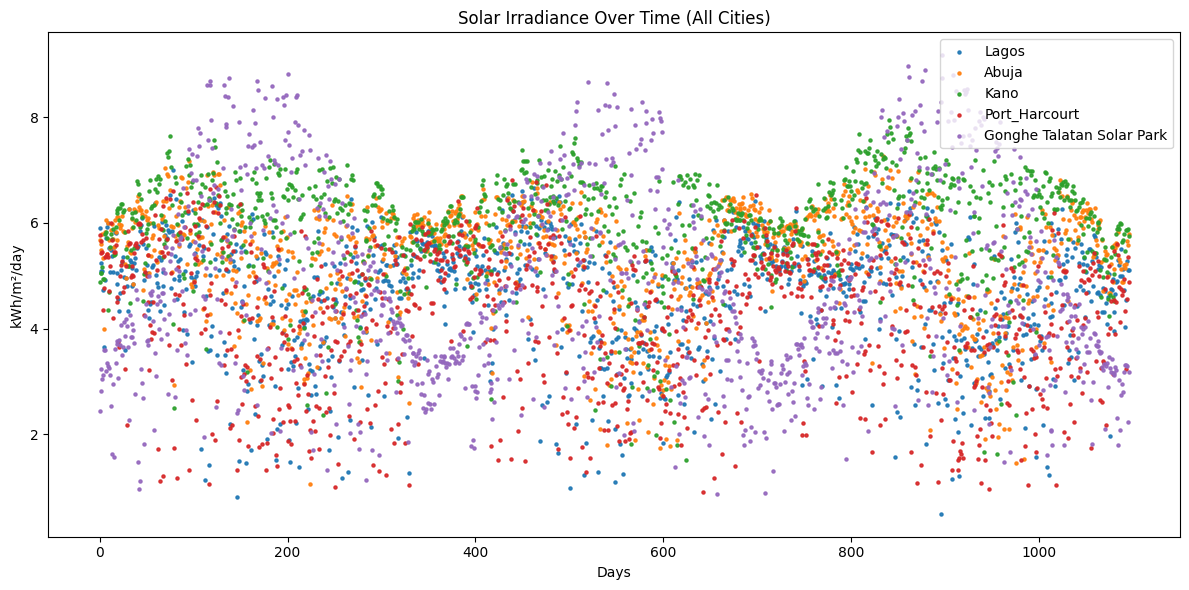

In [147]:
final_df['Day'] = (final_df.index - final_df.index.min()).days

cities = [
    'Lagos(kW-hr/m^2/day)',
    'Abuja(kW-hr/m^2/day)',
    'Kano(kW-hr/m^2/day)',
    'Port_Harcourt(kW-hr/m^2/day)',
    'Gonghe Talatan Solar Park(kW-hr/m^2/day)'
]

plt.figure(figsize=(12,6))

for city in cities:
    plt.scatter(
        final_df['Day'],
        final_df[city],
        s=5,   # point size
        alpha=0.9,
        label=city.split('(')[0]
    )

plt.title("Solar Irradiance Over Time (All Cities)")
plt.xlabel("Days")
plt.ylabel("kWh/m²/day")
plt.legend()
plt.tight_layout()
plt.show()


final_df.drop(columns=['Day'], inplace=True)

In [109]:
# Get the mean irradicance of each state for every year from 2023-2025
mean23 = final_df.loc["2023"].mean()
mean24 = final_df.loc["2024"].mean()
mean25 = final_df.loc["2025"].mean()

yearly_means = pd.DataFrame({
    "2023": mean23,
    "2024": mean24,
    "2025": mean25
})

print(yearly_means)

                                              2023      2024      2025
Lagos(kW-hr/m^2/day)                      4.652152  4.683932  4.535430
Abuja(kW-hr/m^2/day)                      5.350175  5.227650  5.256639
Kano(kW-hr/m^2/day)                       5.896096  5.812691  6.105109
Port_Harcourt(kW-hr/m^2/day)              4.246030  4.320329  4.072007
Gonghe Talatan Solar Park(kW-hr/m^2/day)  4.815394  4.674253  4.904433


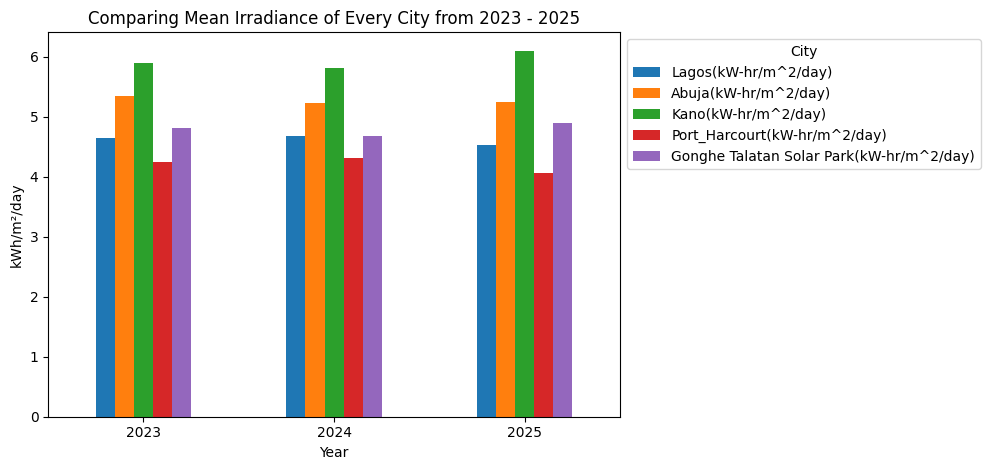

In [152]:
# Plot the mean in a bar chart
yearly_means.T.plot(kind='bar')

plt.title("Comparing Mean Irradiance of Every City from 2023 - 2025")
plt.xlabel("Year")
plt.ylabel("kWh/m²/day")
plt.xticks(rotation=0)
plt.legend(title="City")
plt.tight_layout()
plt.legend(title="City", loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

In [111]:
# Create a season column indicating whether a day falls in dry of rainy season
final_df['Month'] = final_df.index.month

def get_season(month):
    if month in [11, 12, 1, 2, 3]:
        return "Dry"
    else:
        return "Rainy"

final_df['Season'] = final_df['Month'].apply(get_season)
final_df.drop(columns=['Month'], inplace=True)
final_df.head()

,Lagos(kW-hr/m^2/day),Abuja(kW-hr/m^2/day),Kano(kW-hr/m^2/day),Port_Harcourt(kW-hr/m^2/day),Gonghe Talatan Solar Park(kW-hr/m^2/day),Season
Date,,,,,,
2023-01-01,5.9054,5.6690,4.8905,5.7701,2.4336,Dry
2023-01-02,5.2414,5.4823,5.0525,5.6642,3.2434,Dry
2023-01-03,5.0909,5.6033,5.0438,5.4372,2.8272,Dry
2023-01-04,5.0863,5.7953,5.1686,5.4576,3.0396,Dry
2023-01-05,4.7258,5.3410,4.9454,4.3498,3.1171,Dry


In [112]:
# Get the mean irridiance for each location during the dry and rainy seasons
seasonal_means = final_df.groupby('Season').mean()
print(seasonal_means)

        Lagos(kW-hr/m^2/day)  Abuja(kW-hr/m^2/day)  Kano(kW-hr/m^2/day)  \
Season                                                                    
Dry                 5.103598              5.805393             5.890382   
Rainy               4.284662              4.905232             5.971419   

        Port_Harcourt(kW-hr/m^2/day)  Gonghe Talatan Solar Park(kW-hr/m^2/day)  
Season                                                                          
Dry                         4.721034                                  3.680582  
Rainy                       3.853543                                  5.588051  


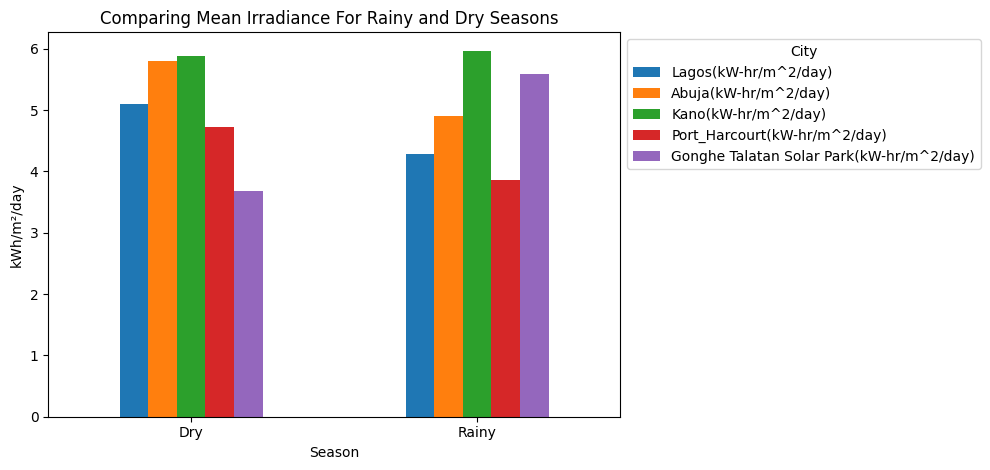

In [151]:
seasonal_means.plot(kind='bar')

plt.title("Comparing Mean Irradiance For Rainy and Dry Seasons  ")
plt.xlabel("Season")
plt.ylabel("kWh/m²/day")
plt.xticks(rotation=0)
plt.legend(title="City")
plt.tight_layout()
plt.legend(title="City", loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

In [114]:
# Percentage drop of Irradiance from dry to rainy season for each state
dry = seasonal_means.loc['Dry']
rainy = seasonal_means.loc['Rainy']
percent_drop = ((dry - rainy) / dry) * 100
print(percent_drop)

Lagos(kW-hr/m^2/day)                        16.046242
Abuja(kW-hr/m^2/day)                        15.505591
Kano(kW-hr/m^2/day)                         -1.375747
Port_Harcourt(kW-hr/m^2/day)                18.375031
Gonghe Talatan Solar Park(kW-hr/m^2/day)   -51.825192
dtype: float64


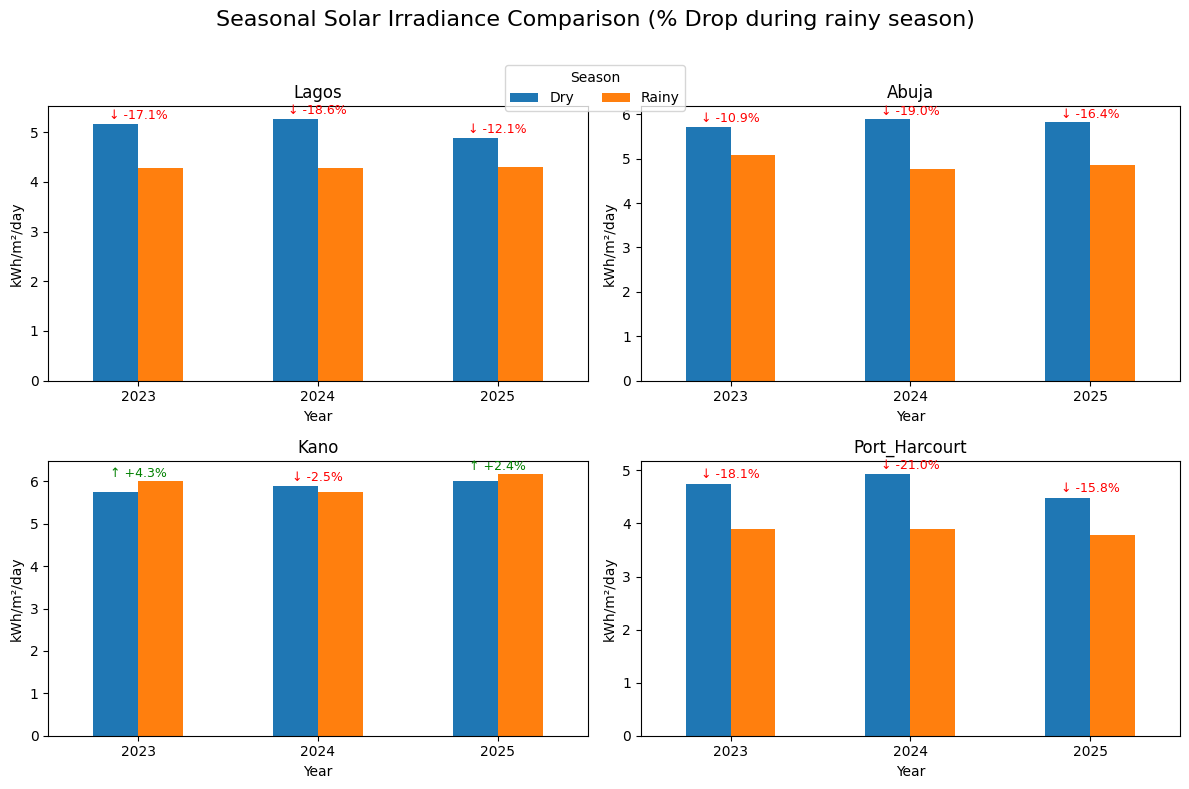

In [148]:
# Plot the mean irradiance for both seasons at a given year for all locations
final_df['Year'] = final_df.index.year
season_year = final_df.groupby(['Year', 'Season']).mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, city in zip(axes.flatten(), cities):
    city_data = season_year[city].unstack()  # Year vs Season

    # Plot bars
    city_data.plot(kind='bar', ax=ax)

    ax.set_title(city.split('(')[0])
    ax.set_xlabel("Year")
    ax.set_ylabel("kWh/m²/day")
    ax.tick_params(axis='x', rotation=0)

    #Compute % drop
    percent_drop = ((city_data['Rainy'] - city_data['Dry']) / city_data['Dry']) * 100

    #Add labels above bars
    for i, (year, drop) in enumerate(percent_drop.items()):
        y_max = city_data.loc[year].max()  # highest bar (Dry)

        if drop < 0:
            ax.text(
                i, y_max + 0.1,                 # position above bars
                f"↓ {drop:.1f}%",               # label text
                ha='center',
                fontsize=9,
                color='red'
            )
        else:
            ax.text(
            i, y_max + 0.1,                 # position above bars
            f"↑ +{drop:.1f}%",               # label text
            ha='center',
            fontsize=9,
            color='green'
        )

    ax.legend().remove()

# Shared legend
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, title="Season", loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.92))
fig.suptitle("Seasonal Solar Irradiance Comparison (% Drop during rainy season)", fontsize=16, y=0.98)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [137]:
# Get number of days with < 3.5 kWh/m²/day for each city from 2023 - 2025
low_days = {city.split('(')[0]: (final_df[city] < 3.5).sum() for city in cities}

low_irr_days = pd.DataFrame.from_dict(low_days, orient='index', columns=['% of Low_Irradiance_Days (from 2023 - 2025)'])
low_irr_days['% of Low_Irradiance_Days (from 2023 - 2025)'] = (low_irr_days['% of Low_Irradiance_Days (from 2023 - 2025)'] / len(final_df)) * 100
low_irr_days = low_irr_days.sort_values('% of Low_Irradiance_Days (from 2023 - 2025)')
low_irr_days


,% of Low_Irradiance_Days (from 2023 - 2025)
Kano,2.919708
Abuja,8.120438
Lagos,16.605839
Gonghe Talatan Solar Park,28.010949
Port_Harcourt,28.558394


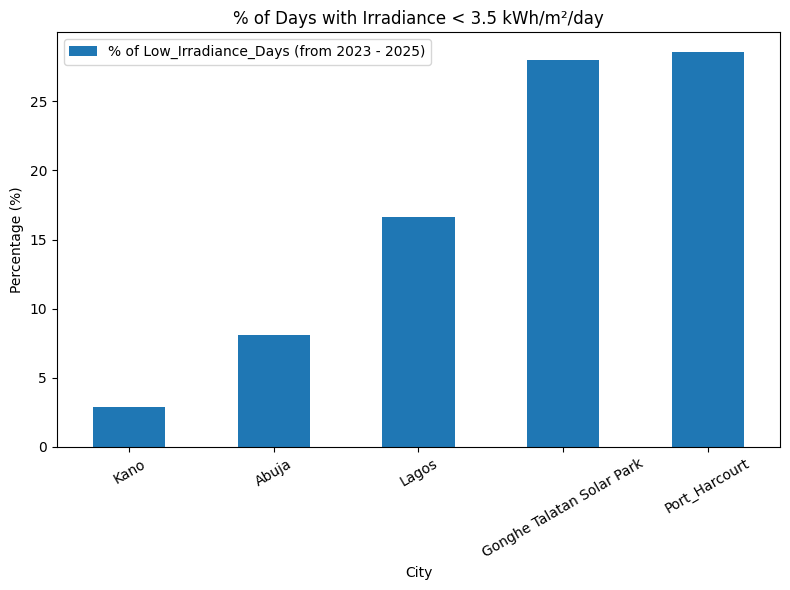

In [149]:
fig, ax = plt.subplots(figsize=(8, 6))

low_irr_days.plot(kind='bar', ax=ax)

ax.set_title("% of Days with Irradiance < 3.5 kWh/m²/day")
ax.set_xlabel("City")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()